In [1]:
from sacrebleu.metrics import BLEU
import re
import nltk
from nltk.tokenize import sent_tokenize
import os
import json
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()

In [2]:
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle') # tokenizer for splitting into sentences

# Helper functions

In [3]:
# Self-BLEU function 

def calculate_self_bleu(sentences, n_gram=4):
    """
    Calculate self-BLEU scores for a set of sentences.
    
    Args:
        sentences: List of sentences to compute self-BLEU for
        n_gram: Maximum n-gram order (default: 4)
    
    Returns:
        float: Average self-BLEU score
    """

    if len(sentences) < 2:
        return "too short"
    
    # Initialize BLEU scorer
    bleu = BLEU(max_ngram_order=n_gram, effective_order=True)


    scores = []
    for i in range(len(sentences)):
        hyp = [sentences[i]]
        # Wrap each other sentence in a list → each becomes a separate reference set
        refs = [[sentences[j]] for j in range(len(sentences)) if j != i]
        score = bleu.corpus_score(hyp, refs)
        scores.append(score.score)

        #print("Hypothesis:", hyp, "References:", refs, "Score:", score.score)

    average_self_bleu = sum(scores) / len(scores)

    
        
    return average_self_bleu


In [4]:
def remove_markdown(text):
    """
    Remove markdown formatting from a sentence.
    
    Args:
        sentence: Input sentence to remove markdown from
    """

    # Remove markdown formatting
    text = re.sub(r'#+', '', text)  # Remove all # symbols
    text = re.sub(r'\*\*', '', text)  # Remove **
    text = re.sub(r'\*', '', text)  # Remove *
    return text

def is_valid_sentence(sentence):
    """
    Check if a sentence is valid (not just a number or numbered list marker)
    Returns True if sentence is valid, False otherwise
    """
    # Strip whitespace
    sentence = sentence.strip()
    
    # Check if sentence is empty
    if not sentence:
        return False
    
    # Remove common markdown formatting characters
    cleaned = sentence.replace('#', '').replace('*', '').strip()
        
    # Check if sentence is just a number followed by a period (like "1.", "2.", "### 8.", "**2.", etc)
    if cleaned.replace('.', '').isdigit():
        return False
        
    # Check if sentence is too short (less than 3 characters)
    if len(cleaned) < 3:
        return False
        
    # Check if sentence starts with a number and period but has no other content
    if cleaned.split('.')[0].isdigit() and len(cleaned.split('.')) <= 2:
        return False
    
    return True


# Calculating self-bleu for 100 responses per dataset

### Data paths

In [5]:
model_paths = {
    "Small": [
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_2_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl",
        "../../Data/Finetuning/Augmented/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl", # above here == small
    ],
    "Medium": [
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_2_Llama.jsonl", 
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_2_Mistral.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_3_Qwen.jsonl",
        "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_4_Command.jsonl",  # above here == medium
    ],
    "Large":[
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_1_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_2_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_3_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_4_Llama.jsonl",
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl", 
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_3_GPT.jsonl",
        "../../Data/Finetuning/Augmented/Large/Other/dolly_train_4_Deepseek.jsonl",  # above here == large
    ]
}


## Model sentences

In [6]:
def self_bleu_individual_responses_model(data_paths, output_base_dir="../../Data/analysis/self_bleu", sample_number=500, save=False, n_gram=4, seed=42):
    """
    Calculate self-BLEU scores for individual responses from each dataset.
    
    Args:
        data_paths: Dictionary mapping model sizes to lists of file paths
        output_base_dir: Directory to save the results
        sample_number: Number of samples to use for calculation
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)

            clean_model_responses = []

            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                clean_model_responses.append(clean_sentences) 
                
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]

            self_bleu_4_scores = []
            lexical_diversity_scores = [] 

            too_short = 0
            
            for sample in response_samples:

                if len(sample) < 2:
                    too_short += 1
                    continue
                else:
                    self_bleu_4 = calculate_self_bleu(sample, n_gram)
                    lexical_diversity = 100-self_bleu_4
                    self_bleu_4_scores.append(self_bleu_4)
                    lexical_diversity_scores.append(lexical_diversity)

            print(f"Too short: {too_short/len(response_samples)}")

            average_self_bleu_4 = np.mean(self_bleu_4_scores)
            average_lexical_diversity = np.mean(lexical_diversity_scores)
            
            if save:
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        "average_self_bleu_4": average_self_bleu_4,
                        "average_lexical_diversity": average_lexical_diversity,
                        "response_samples": response_samples,
                        "self_bleu_4_scores": self_bleu_4_scores,
                        "lexical_diversity_scores": lexical_diversity_scores
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




In [7]:
def self_bleu_all_responses_model(data_paths, output_base_dir="../../Data/analysis/self_bleu_combined", sample_number=100, save=False, n_gram=4, seed=42):
    """
    Calculate Self-BLEU scores for all model responses.
    
    Args:
        data_paths: Dictionary mapping size to list of file paths
        output_base_dir: Directory to save results
        sample_number: Number of responses to sample
        seed: Random seed for reproducibility
    """
    # Create output directories
    for size in ["Small", "Medium", "Large"]:
        os.makedirs(os.path.join(output_base_dir, size), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each dataset
    for size, file_paths in data_paths.items():
        print(f"Processing {size} models...")
        
        for file_path in tqdm(file_paths):
            # Extract model name from file path
            file_name = os.path.basename(file_path)
            model_name = file_name.split('.')[0]
            
            # Initialize data containers
            all_model_responses = []
            clean_model_responses = []
            
            # Load the data
            with open(file_path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
                    response_model = data[response_key_model]
                    all_model_responses.append(response_model)


            # Tokenize all responses
            for response_model in all_model_responses:
                response_model_sentences = sent_tokenize(response_model)
                valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
                clean_sentences = [remove_markdown(s) for s in valid_sentences]
                clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
                
                # Filter out responses that are too short to match with individual conditions
                if len(clean_sentences) >= 2:
                    clean_model_responses.append(clean_sentences) 
                

            # Alternative approach if you need to sample whole responses
            indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
            response_samples = [clean_model_responses[i] for i in indices]


            joined_responses = " ".join([s for sublist in response_samples for s in sublist])
            response_sentences = sent_tokenize(joined_responses)
            response_sentences = [s for s in response_sentences if len(s.split()) >= 4]


            self_bleu_4 = calculate_self_bleu(response_sentences, n_gram)
            lexical_diversity = 100-self_bleu_4



            if save: 
                # Save self-bleu scores
                model_output_file = os.path.join(output_base_dir, size, f"{model_name}_self_bleu.jsonl")
                with open(model_output_file, 'w') as f:
                    entry = {
                        "source": model_name,
                        #"self_bleu_1": self_bleu_1,
                        #"self_bleu_2": self_bleu_2,
                        #"self_bleu_3": self_bleu_3,
                        "self_bleu_4": self_bleu_4,
                        #"self_bleu_average": self_bleu_average,
                        "lexical_diversity": lexical_diversity,
                        "response_sentences": response_sentences
                    }
                    f.write(json.dumps(entry) + '\n')
                
                print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")




## Human sentences

In [8]:
# Config

human_paths = [
    "../../Data/Finetuning/Dolly/dolly_train_1.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_3.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_4.jsonl"
]
def self_bleu_individual_responses_human(data_paths_human, output_base_dir, sample_number=500, save=False, n_gram=4, seed=42):
    """
    Process human datasets to calculate self-BLEU scores and lexical diversity.
    
    Args:
        data_paths_human: List of paths to human dataset files
        output_base_dir: Base directory to save output files
        sample_number: Number of samples to use (default: 500)
        seed: Random seed for reproducibility (default: 42)
    """
    # Create output directories
    os.makedirs(os.path.join(output_base_dir, "Human"), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each human dataset
    print("Processing human datasets...")

    for file_path in tqdm(data_paths_human):
        # Extract dataset name from file path
        file_name = os.path.basename(file_path)
        dataset_name = file_name.split('.')[0]
        
        # Initialize data containers
        all_human_responses = []
        clean_human_responses = []
        
        # Load the data
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Get the human response (typically the first response key)
                response_key_human = [k for k in data.keys() if k.startswith('response_human')][0]
                response_human = data[response_key_human]
                all_human_responses.append(response_human)
        
        # Tokenize all responses
        for response_human in all_human_responses:
            response_human_sentences = sent_tokenize(response_human)
            valid_sentences = [s for s in response_human_sentences if is_valid_sentence(s)]
            clean_sentences = [remove_markdown(s) for s in valid_sentences]
            clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
            clean_human_responses.append(clean_sentences) # this is where either a list of lists or a list of strings is stored (append or extend)
                

        # Alternative approach if you need to sample whole responses
        indices = np.random.choice(len(clean_human_responses), size=sample_number, replace=False)
        response_samples = [clean_human_responses[i] for i in indices]

        self_bleu_4_scores = []
        lexical_diversity_scores = []
        
        too_short = 0
            
        for sample in response_samples:

            if len(sample) < 2:
                too_short += 1
                continue
            else:
                self_bleu_4 = calculate_self_bleu(sample, n_gram)
                lexical_diversity = 100-self_bleu_4
                self_bleu_4_scores.append(self_bleu_4)
                lexical_diversity_scores.append(lexical_diversity)

        print(f"Too short: {too_short/len(response_samples)}")

        average_self_bleu_4 = np.mean(self_bleu_4_scores)
        average_lexical_diversity = np.mean(lexical_diversity_scores)

        if save: 
            # Save self-bleu scores
            model_output_file = os.path.join(output_base_dir, "Human", f"{dataset_name}_self_bleu.jsonl")
            with open(model_output_file, 'w') as f:
                entry = {
                    "source": dataset_name,
                    "average_self_bleu_4": average_self_bleu_4,
                    "average_lexical_diversity": average_lexical_diversity,
                    "response_samples": response_samples,
                    "self_bleu_4_scores": self_bleu_4_scores,
                    "self_bleu_4_scores": self_bleu_4_scores,
                    "lexical_diversity_scores": lexical_diversity_scores
                }
                f.write(json.dumps(entry) + '\n')
            
            print(f"  Saved self-bleu scores to {model_output_file}")

    print("All self-bleu scores have been calculated.")


In [9]:
def self_bleu_all_responses_human(data_paths_human, output_base_dir, sample_number=100, save=False, n_gram=4, seed=42):
    """
    Calculate Self-BLEU scores for all human responses combined.
    
    Args:
        data_paths_human: List of paths to human response data files
        output_base_dir: Base directory to save output files
        sample_number: Number of responses to sample (default: 100)
    """
    # Create output directories
    os.makedirs(os.path.join(output_base_dir, "Human"), exist_ok=True)

    np.random.seed(seed)  # Set seed for reproducibility

    # Process each human dataset
    print("Processing human datasets...")

    for file_path in tqdm(data_paths_human):
        # Extract dataset name from file path
        file_name = os.path.basename(file_path)
        dataset_name = file_name.split('.')[0]
        
        # Initialize data containers
        all_human_responses = []
        clean_human_responses = []
        
        # Load the data
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Get the human response (typically the first response key)
                response_key_human = [k for k in data.keys() if k.startswith('response_human')][0]
                response_human = data[response_key_human]
                all_human_responses.append(response_human)
        
        # Tokenize all responses
        for response_human in all_human_responses:
            response_human_sentences = sent_tokenize(response_human)
            valid_sentences = [s for s in response_human_sentences if is_valid_sentence(s)]
            clean_sentences = [remove_markdown(s) for s in valid_sentences]
            clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
            # Filter out responses that are too short to match with individual conditions
            if len(clean_sentences) >= 2:
                clean_human_responses.append(clean_sentences)                

        # Alternative approach if you need to sample whole responses
        indices = np.random.choice(len(clean_human_responses), size=sample_number, replace=False)
        response_samples = [clean_human_responses[i] for i in indices]


        joined_responses = " ".join([s for sublist in response_samples for s in sublist])
        response_sentences = sent_tokenize(joined_responses)
        response_sentences = [s for s in response_sentences if len(s.split()) >= 4]

        
        self_bleu_4 = calculate_self_bleu(response_sentences, n_gram)
        lexical_diversity = 100-self_bleu_4

        if save: 
            # Save self-bleu scores
            human_output_file = os.path.join(output_base_dir, "Human", f"{dataset_name}_self_bleu.jsonl")
            with open(human_output_file, 'w') as f:
                entry = {
                    "source": dataset_name,
                    "self_bleu_4": self_bleu_4,
                    "lexical_diversity": lexical_diversity,
                    "response_sentences": response_sentences
                }
                f.write(json.dumps(entry) + '\n')
            
            print(f"  Saved self-bleu scores to {human_output_file}")

    print("All self-bleu scores have been calculated.")


## Calculate scores

In [14]:
# Self-BLEU model scores for individual responses
save = True
n_gram = 3
sample_number = 500
output_base_dir = f"../../Data/analysis/self_bleu_{n_gram}"
self_bleu_individual_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 14%|█▍        | 1/7 [00:02<00:15,  2.57s/it]

Too short: 0.176
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Small/dolly_train_1_Llama_self_bleu.jsonl


 29%|██▊       | 2/7 [00:05<00:12,  2.54s/it]

Too short: 0.17
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Small/dolly_train_2_Llama_self_bleu.jsonl


...

Too short: 0.368
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_2_Gemini_self_bleu.jsonl


 86%|████████▌ | 6/7 [00:16<00:02,  2.87s/it]

Too short: 0.152
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_3_GPT_self_bleu.jsonl


100%|██████████| 7/7 [00:19<00:00,  2.83s/it]

Too short: 0.106
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Large/dolly_train_4_Deepseek_self_bleu.jsonl
All self-bleu scores have been calculated.


In [15]:
# Self-BLEU model scores for all responses

save = True
sample_number = 100
output_base_dir = f"../../Data/analysis/self_bleu_combined_{n_gram}"
self_bleu_all_responses_model(model_paths, output_base_dir, sample_number, save, n_gram)

Processing Small models...


 14%|█▍        | 1/7 [00:33<03:21, 33.55s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Small/dolly_train_1_Llama_self_bleu.jsonl


 29%|██▊       | 2/7 [01:12<03:02, 36.54s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Small/dolly_train_2_Llama_self_bleu.jsonl


...

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_2_Gemini_self_bleu.jsonl


 86%|████████▌ | 6/7 [05:22<00:55, 55.05s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_3_GPT_self_bleu.jsonl


100%|██████████| 7/7 [06:20<00:00, 54.32s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Large/dolly_train_4_Deepseek_self_bleu.jsonl
All self-bleu scores have been calculated.


In [16]:
#  Self-BLEU human scores for individual responses

save = True
sample_number = 500
output_base_dir = f"../../Data/analysis/self_bleu_{n_gram}"

self_bleu_individual_responses_human(human_paths, output_base_dir, sample_number, save, n_gram)

Processing human datasets...


 25%|██▌       | 1/4 [00:00<00:02,  1.34it/s]

Too short: 0.534
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_1_self_bleu.jsonl


 50%|█████     | 2/4 [00:01<00:01,  1.43it/s]

Too short: 0.514
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_2_self_bleu.jsonl


 75%|███████▌  | 3/4 [00:02<00:00,  1.44it/s]

Too short: 0.474
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_3_self_bleu.jsonl


100%|██████████| 4/4 [00:02<00:00,  1.41it/s]

Too short: 0.474
  Saved self-bleu scores to ../../Data/analysis/self_bleu_3/Human/dolly_train_4_self_bleu.jsonl
All self-bleu scores have been calculated.


In [17]:
# Self-BLEU human scores for all responses

save = True
sample_number = 100
output_base_dir = f"../../Data/analysis/self_bleu_combined_{n_gram}"
self_bleu_all_responses_human(human_paths, output_base_dir, sample_number, save, n_gram)

Processing human datasets...


 25%|██▌       | 1/4 [00:17<00:52, 17.43s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_1_self_bleu.jsonl


 50%|█████     | 2/4 [00:34<00:33, 16.98s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_2_self_bleu.jsonl


 75%|███████▌  | 3/4 [00:44<00:14, 14.16s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_3_self_bleu.jsonl


100%|██████████| 4/4 [00:56<00:00, 14.17s/it]

  Saved self-bleu scores to ../../Data/analysis/self_bleu_combined_3/Human/dolly_train_4_self_bleu.jsonl
All self-bleu scores have been calculated.


# Plotting self-bleu scores

## Creating summary datasets

In [20]:
# Initialize lists to store data
n_gram = 4
self_bleu_data = []

# Process each directory
for size in ["Human", "Small", "Medium", "Large"]:
    dir_path = f"../../Data/analysis/self_bleu_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data.append({
                        "dataset": entry["source"].split("_")[0] + "_" + entry["source"].split("_")[1] + "_" + entry["source"].split("_")[2],
                        "model": entry["source"].split("_")[-1] if len(entry["source"].split("_")) > 2 else "Human",
                        "size": size,
                        f"self_bleu_{n_gram}": entry["average_self_bleu_4"],
                        "lexical_diversity": entry["average_lexical_diversity"],
                        "lexical_diversity_scores": entry["lexical_diversity_scores"]
                    })

# Create DataFrame
df = pd.DataFrame(self_bleu_data)

# Sort by size and source
df = df.sort_values(["size", "model", "dataset"])
# Reset the index of the DataFrame
df = df.reset_index(drop=True)
# Assuming 'df' is your DataFrame
df.loc[0:3, 'model'] = 'Human'

df.loc[18, 'model'] = 'Falcon'
df.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
df.head(25)

,dataset,model,size,self_bleu_4,lexical_diversity,lexical_diversity_scores
0,dolly_train_1,Human,Human,7.264739,92.735261,"[92.42387853708763, 93.47514519991132, 98.5736..."
1,dolly_train_2,Human,Human,7.232833,92.767167,"[97.45404698649499, 90.7441933042195, 95.60194..."
2,dolly_train_3,Human,Human,7.754770,92.245230,"[91.39061509559372, 41.772067556870375, 98.574..."
3,dolly_train_4,Human,Human,7.486377,92.513623,"[90.59448271270782, 97.85540757653855, 91.5796..."
4,dolly_train_4,Deepseek,Large,12.250364,87.749636,"[90.87426631640261, 94.72288924676903, 80.4301..."
5,dolly_train_3,GPT,Large,11.629938,88.370062,"[90.9314216129955, 90.76242050388312, 56.51551..."
6,dolly_train_2,Gemini,Large,12.367377,87.632623,"[66.74105704313314, 85.51083484854834, 98.2723..."
7,dolly_train_1,Llama,Large,14.622396,85.377604,"[83.16113669989906, 96.24135933591624, 88.1528..."
8,dolly_train_2,Llama,Large,14.268462,85.731538,"[98.2014636591495, 88.3834826540536, 56.614728..."
9,dolly_train_3,Llama,Large,15.159793,84.840207,"[70.51568052963377, 76.2148426697768, 98.99632..."


In [23]:
# SELF BLEU COMBINED
# Initialize lists to store data
n_gram = 4
self_bleu_data_combined = []

# Process each directory
for size in ["Human", "Small", "Medium", "Large"]:
    dir_path = f"../../Data/analysis/self_bleu_combined_{n_gram}/{size}"
    
    # Process each file in the directory
    for file in os.listdir(dir_path):
        if file.endswith(".jsonl"):
            file_path = os.path.join(dir_path, file)
            
            # Read the JSONL file
            with open(file_path, 'r') as f:
                for line in f:
                    entry = json.loads(line)
                    
                    # Extract the data we need
                    self_bleu_data_combined.append({
                        "dataset": entry["source"].split("_")[0] + "_" + entry["source"].split("_")[1] + "_" + entry["source"].split("_")[2],
                        "model": entry["source"].split("_")[-1] if len(entry["source"].split("_")) > 2 else "Human",
                        "size": size,
                        f"self_bleu_{n_gram}": entry["self_bleu_4"],
                        "lexical_diversity": entry["lexical_diversity"],
                    })

# Create DataFrame
df_combined = pd.DataFrame(self_bleu_data_combined)

# Sort by size and source
df_combined = df_combined.sort_values(["size", "model", "dataset"])
# Reset the index of the DataFrame
df_combined = df_combined.reset_index(drop=True)
df_combined.loc[0:3, 'model'] = 'Human'
df_combined.loc[18, 'model'] = 'Falcon'
df_combined.to_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")
df_combined.head(25)

,dataset,model,size,self_bleu_4,lexical_diversity
0,dolly_train_1,Human,Human,18.156057,81.843943
1,dolly_train_2,Human,Human,15.011641,84.988359
2,dolly_train_3,Human,Human,15.263775,84.736225
3,dolly_train_4,Human,Human,16.987418,83.012582
4,dolly_train_4,Deepseek,Large,21.385177,78.614823
5,dolly_train_3,GPT,Large,22.243191,77.756809
6,dolly_train_2,Gemini,Large,24.298829,75.701171
7,dolly_train_1,Llama,Large,30.715078,69.284922
8,dolly_train_2,Llama,Large,29.125735,70.874265
9,dolly_train_3,Llama,Large,25.699093,74.300907


## Load data

In [2]:
n_gram = 3
df = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
df_aggregated = pd.read_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")

# Group by 'size' and calculate the mean for each metric
avg_by_size = df.groupby('size')[[f'self_bleu_{n_gram}', 'lexical_diversity']].mean().reset_index()

avg_by_size_aggregated = df_aggregated.groupby('size')[[f'self_bleu_{n_gram}', 'lexical_diversity']].mean().reset_index()


avg_by_size.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size.pkl")
avg_by_size_aggregated.to_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/avg_by_size_aggregated.pkl")


In [29]:
# Concatenate avg_by_size and avg_by_size_combined

# First, add a column to identify the source of each dataframe
avg_by_size['Preprocessing'] = 'individual responses'
avg_by_size_aggregated['Preprocessing'] = 'aggregated responses'

# Concatenate the dataframes
avg_by_size_all = pd.concat([avg_by_size, avg_by_size_aggregated], ignore_index=True)

avg_by_size_all.to_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size_all.pkl")

avg_by_size_all.head(10)


,size,self_bleu_3,lexical_diversity,Preprocessing
0,Human,10.841940,89.158060,individual responses
1,Large,19.043206,80.956794,individual responses
2,Medium,21.107692,78.892308,individual responses
3,Small,20.497975,79.502025,individual responses
4,Human,25.811892,74.188108,aggregated responses
5,Large,37.413133,62.586867,aggregated responses
6,Medium,39.742667,60.257333,aggregated responses
7,Small,39.191644,60.808356,aggregated responses


## Plot

### Summary plot

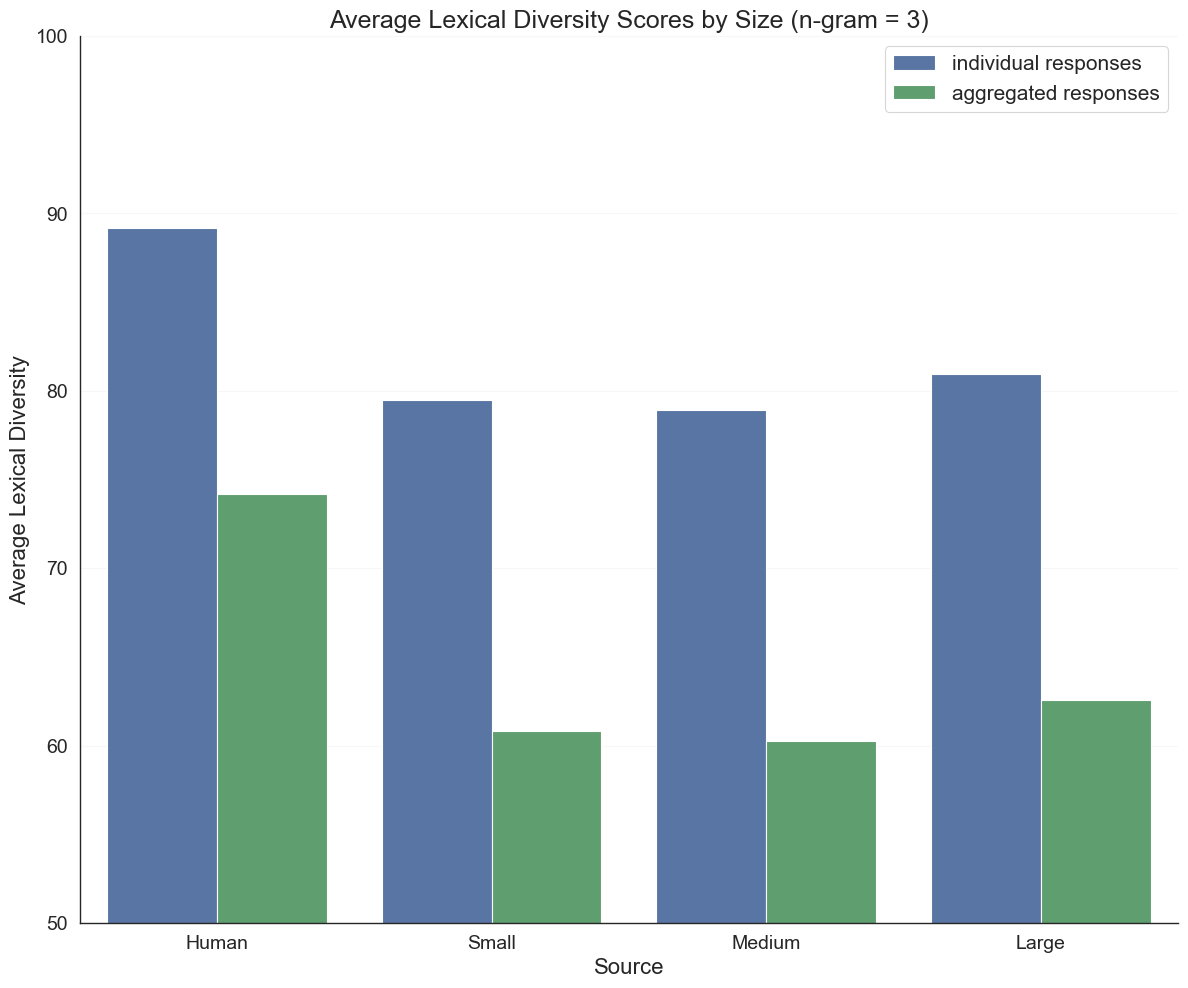

In [25]:
n_gram = 3
avg_by_size_all = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/avg_by_size_all.pkl")

# Create the bar plot with reordered categories
plt.figure(figsize=(12, 10))
plt.grid(True, linestyle='-', alpha=0.3)
sns.barplot(
    data=avg_by_size_all, 
    x="size", 
    y="lexical_diversity", 
    hue="Preprocessing", 
    order=["Human", "Small", "Medium", "Large"]
)

plt.title(f"Average Lexical Diversity Scores by Size (n-gram = {n_gram})", fontsize=18)
plt.ylabel("Average Lexical Diversity", fontsize=16)
plt.xlabel("Source", fontsize=16)

# Set y-axis grid lines every 10 steps
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)

# Increase x-axis tick font size
plt.xticks(fontsize=14)
plt.ylim(50, 100)

# Increase legend font size
plt.legend(fontsize=15)

plt.tight_layout()
plt.show()

### Individual models

In [16]:
n_gram = 3

self_bleu_data = pd.read_pickle(f"../../Data/analysis/self_bleu_{n_gram}/self_bleu_data.pkl")
self_bleu_data_combined = pd.read_pickle(f"../../Data/analysis/self_bleu_combined_{n_gram}/self_bleu_combined_data.pkl")

# Define the order for size categories
size_order = ["Human", "Small", "Medium", "Large"]

# Convert 'size' column to categorical type with the specified order
self_bleu_data['size'] = pd.Categorical(self_bleu_data['size'], categories=size_order, ordered=True)
self_bleu_data_combined['size'] = pd.Categorical(self_bleu_data_combined['size'], categories=size_order, ordered=True)

# Sort the dataframes by 'size'
self_bleu_data = self_bleu_data.sort_values('size')
self_bleu_data_combined = self_bleu_data_combined.sort_values('size')

# Reset the index of self_bleu_data
self_bleu_data.reset_index(drop=True, inplace=True)
self_bleu_data_combined.reset_index(drop=True, inplace=True)

self_bleu_data.at[10, 'model'] = 'Qwen'
self_bleu_data_combined.at[10, 'model'] = 'Qwen'

# Swap the row at index 11 with that at index 17
self_bleu_data.iloc[[11, 17]] = self_bleu_data.iloc[[17, 11]].values

self_bleu_data_combined.head(25)


,dataset,model,size,self_bleu_3,lexical_diversity
0,dolly_train_1,Human,Human,27.817671,72.182329
1,dolly_train_2,Human,Human,24.425078,75.574922
2,dolly_train_3,Human,Human,24.936844,75.063156
3,dolly_train_4,Human,Human,26.067974,73.932026
4,dolly_train_3,Llama,Small,46.347424,53.652576
5,dolly_train_2,Llama,Small,44.595332,55.404668
6,dolly_train_1,Llama,Small,43.223165,56.776835
7,dolly_train_2,Gemma,Small,30.728718,69.271282
8,dolly_train_4,Falcon,Small,33.136307,66.863693
9,dolly_train_4,Llama,Small,43.809057,56.190943


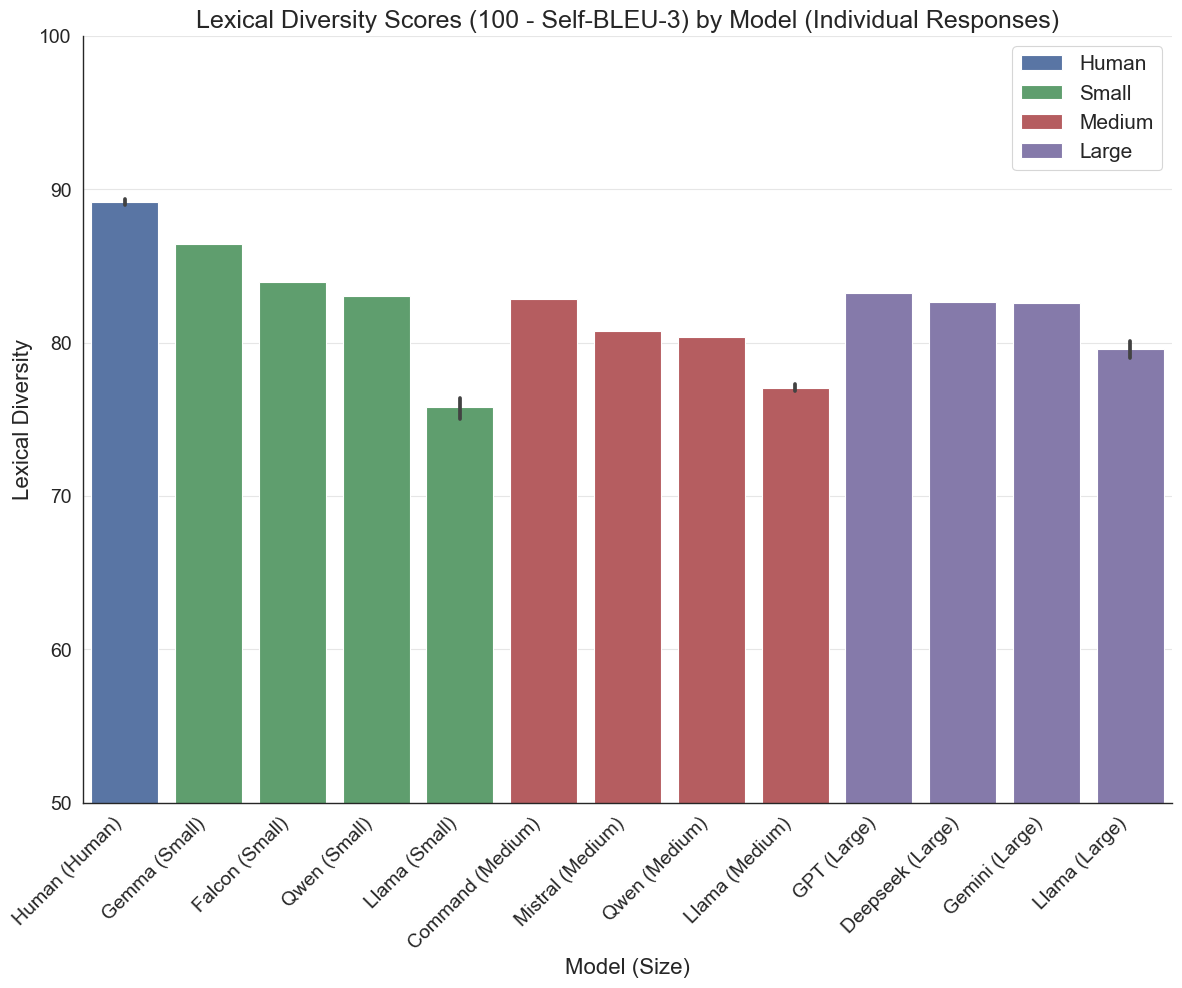

In [21]:
# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(12, 10))

# Add a new column to combine model name and size
self_bleu_data['model_with_size'] = self_bleu_data['model'] + ' (' + self_bleu_data['size'].astype(str) + ')'

# Use the thesis color palette instead of hardcoded colors
# Get the current palette set by thesis style
current_palette = sns.color_palette()

# Map sizes to colors from the thesis palette
size_palette = {
    "Human": current_palette[0],    # Red from thesis palette
    "Small": current_palette[1],    # Sand/yellow from thesis palette  
    "Medium": current_palette[2],   # Green from thesis palette
    "Large": current_palette[3]     # Blue from thesis palette
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_sorted = self_bleu_data.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with thesis style colors
sns.barplot(
    data=self_bleu_data_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',
    palette=size_palette,
    dodge=False
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Individual Responses)", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.ylabel("Lexical Diversity", fontsize=16)
plt.xlabel("Model (Size)", fontsize=16)
plt.ylim(50, 100)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

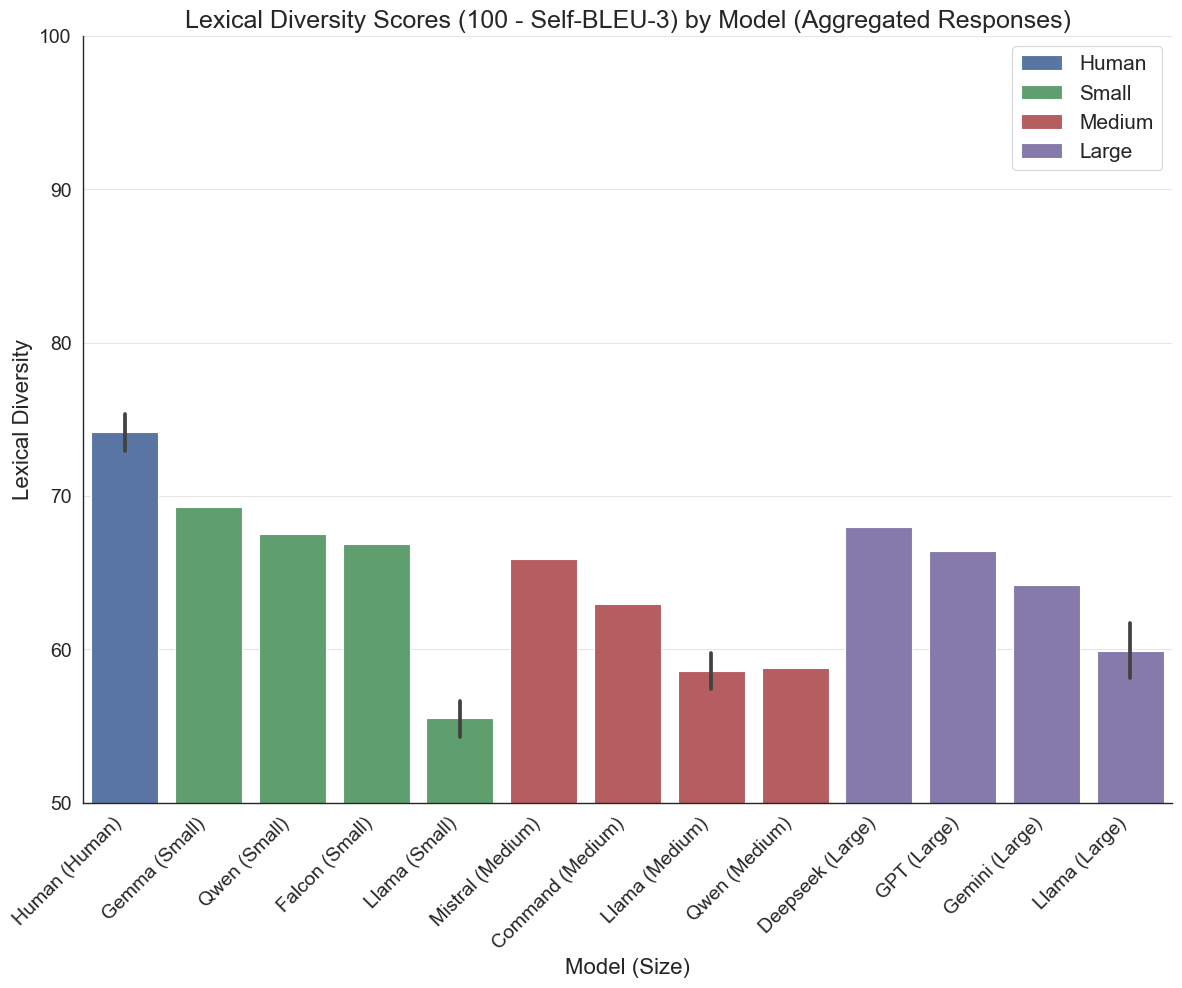

In [23]:
n_gram = 3

# Create a plot to visualize self_bleu scores by model, split by size
plt.figure(figsize=(12, 10))

# Add a new column to combine model name and size
self_bleu_data_combined['model_with_size'] = self_bleu_data_combined['model'] + ' (' + self_bleu_data_combined['size'].astype(str) + ')'

# Use the thesis color palette instead of hardcoded colors
# Get the current palette set by thesis style
current_palette = sns.color_palette()

# Map sizes to colors from the thesis palette
size_palette = {
    "Human": current_palette[0],    # Red from thesis palette
    "Small": current_palette[1],    # Sand/yellow from thesis palette  
    "Medium": current_palette[2],   # Green from thesis palette
    "Large": current_palette[3]     # Blue from thesis palette
}

# Sort the data within each size by lexical diversity score in descending order
self_bleu_data_combined_sorted = self_bleu_data_combined.sort_values(by=['size', 'lexical_diversity'], ascending=[True, False])

# Create the bar plot with thesis style colors
sns.barplot(
    data=self_bleu_data_combined_sorted,
    x='model_with_size',
    y='lexical_diversity',
    hue='size',
    palette=size_palette,
    dodge=False
)

plt.title(f"Lexical Diversity Scores (100 - Self-BLEU-{n_gram}) by Model (Aggregated Responses)", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 10), fontsize=14)
plt.ylabel("Lexical Diversity", fontsize=16)
plt.xlabel("Model (Size)", fontsize=16)
plt.ylim(50, 100)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()


# Calculate self-BLEU scores for gemini with and without system prompts


Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    18.421606          81.578394
1  dolly_train_2  Gemini_with_system  Large    17.088087          82.911913


/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_61754/670297365.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


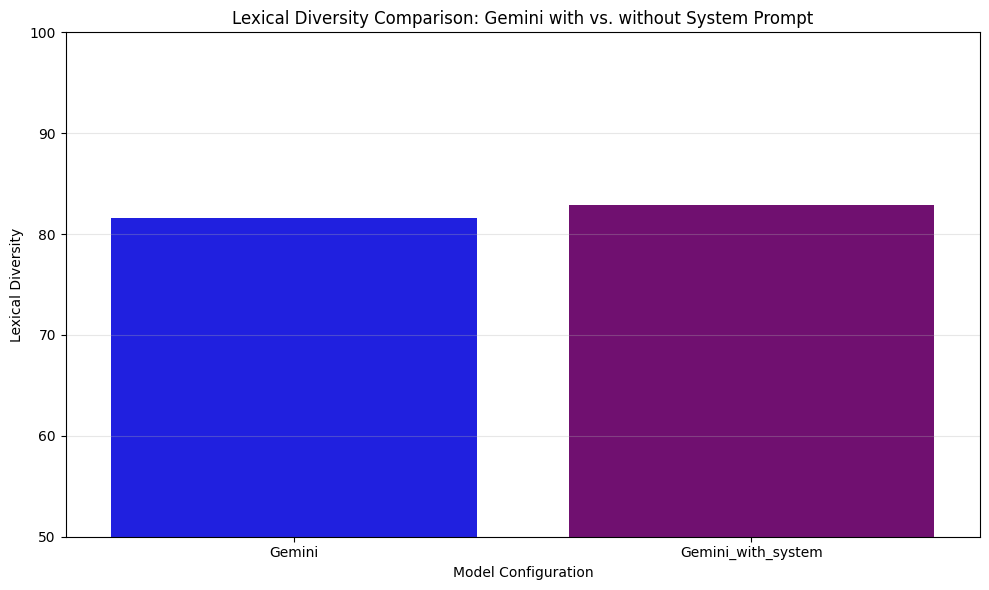

In [9]:
n_gram = 3

# Load the Gemini datasets with and without system prompts
gemini_without_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl"
gemini_with_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini_with_system_prompt.jsonl"

# Function to load and process the data
def load_jsonl_data(file_path, sample_number=500):
    all_model_responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
            response_model = data[response_key_model]
            all_model_responses.append(response_model)


    clean_model_responses = []

    # Tokenize all responses
    for response_model in all_model_responses:
        response_model_sentences = sent_tokenize(response_model)
        valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        clean_model_responses.append(clean_sentences) 
        
    indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
    response_samples = [clean_model_responses[i] for i in indices]
            
    return response_samples


gemini_without_system_responses = load_jsonl_data(gemini_without_system)
gemini_with_system_responses = load_jsonl_data(gemini_with_system)

self_bleu_4_scores_without_system = []
self_bleu_4_scores_with_system = []
lexical_diversity_scores_without_system = [] 
lexical_diversity_scores_with_system = [] 

too_short = 0

for sample1, sample2 in zip(gemini_without_system_responses, gemini_with_system_responses):

    if len(sample1) < 2:
        too_short += 1
        continue
    elif len(sample2) < 2:
        too_short += 1
        continue
    else:
        self_bleu_4 = calculate_self_bleu(sample1, n_gram)
        lexical_diversity = 100-self_bleu_4
        self_bleu_4_scores_without_system.append(self_bleu_4)
        lexical_diversity_scores_without_system.append(lexical_diversity)

        self_bleu_4 = calculate_self_bleu(sample2, n_gram)
        lexical_diversity = 100-self_bleu_4
        self_bleu_4_scores_with_system.append(self_bleu_4)
        lexical_diversity_scores_with_system.append(lexical_diversity)



average_self_bleu_without_system = np.mean(self_bleu_4_scores_without_system)
average_self_bleu_with_system = np.mean(self_bleu_4_scores_with_system)

average_lexical_diversity_without_system = np.mean(lexical_diversity_scores_without_system)
average_lexical_diversity_with_system = np.mean(lexical_diversity_scores_with_system)
    


# Create a DataFrame to compare the results
gemini_comparison = pd.DataFrame({
    'dataset': ['dolly_train_2', 'dolly_train_2'],
    'model': ['Gemini', 'Gemini_with_system'],
    'size': ['Large', 'Large'],
    'self_bleu_' + str(n_gram): [average_self_bleu_without_system, average_self_bleu_with_system],
    'lexical_diversity': [average_lexical_diversity_without_system, average_lexical_diversity_with_system]
})

print("\nComparison of Gemini with and without system prompt:")
print(gemini_comparison)

# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.grid(True, linestyle='-', alpha=0.3)

sns.barplot(
    data=gemini_comparison,
    x='model',
    y='lexical_diversity',
    palette=['blue', 'purple']
)

plt.title(f"Lexical Diversity Comparison: Gemini with vs. without System Prompt")
plt.ylabel("Lexical Diversity")
plt.xlabel("Model Configuration")
plt.ylim(50, 100)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()



Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    18.421606          81.578394
1  dolly_train_2  Gemini_with_system  Large    17.088087          82.911913


/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_61754/4032037436.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


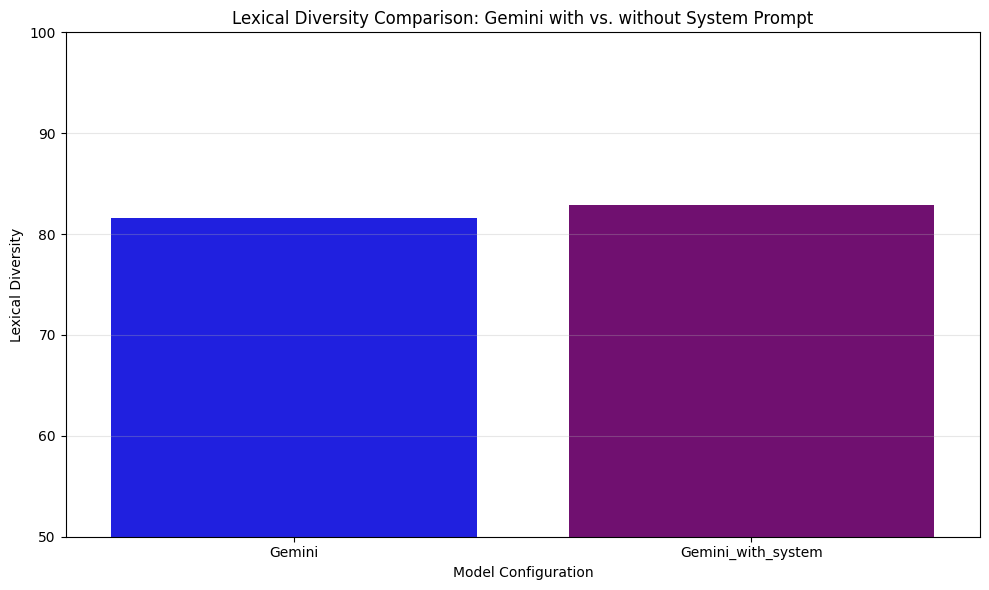

In [ ]:
n_gram = 3

# Load the Gemini datasets with and without system prompts
gemini_without_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl"
gemini_with_system = "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini_with_system_prompt.jsonl"

# Function to load and process the data
def load_jsonl_data(file_path, sample_number=100):
    all_model_responses = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key_model = [k for k in data.keys() if k.startswith('response_')][1]
            response_model = data[response_key_model]
            all_model_responses.append(response_model)


    clean_model_responses = []

    # Tokenize all responses
    for response_model in all_model_responses:
        response_model_sentences = sent_tokenize(response_model)
        valid_sentences = [s for s in response_model_sentences if is_valid_sentence(s)]
        clean_sentences = [remove_markdown(s) for s in valid_sentences]
        clean_sentences = [s for s in clean_sentences if len(s.split()) >= 4]
        clean_model_responses.append(clean_sentences) 
        
    indices = np.random.choice(len(clean_model_responses), size=sample_number, replace=False)
    response_samples = [clean_model_responses[i] for i in indices]
            
    return response_samples


gemini_without_system_responses = load_jsonl_data(gemini_without_system)
gemini_with_system_responses = load_jsonl_data(gemini_with_system)

self_bleu_4_scores_without_system = []
self_bleu_4_scores_with_system = []
lexical_diversity_scores_without_system = [] 
lexical_diversity_scores_with_system = [] 


sentences_gemini_without_system = [sentence for sample in gemini_without_system_responses for sentence in sample]
sentences_gemini_with_system = [sentence for sample in gemini_with_system_responses for sentence in sample]



self_bleu_4_without_system = calculate_self_bleu(sentences_gemini_without_system, n_gram)
lexical_diversity_without_system = 100-self_bleu_4_without_system

self_bleu_4_with_system = calculate_self_bleu(sentences_gemini_with_system, n_gram)
lexical_diversity_with_system = 100-self_bleu_4_with_system
    



# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.grid(True, linestyle='-', alpha=0.3)

sns.barplot(
    data=gemini_comparison,
    x='model',
    y='lexical_diversity',
    palette=['blue', 'purple']
)

plt.title(f"Lexical Diversity Comparison: Gemini with vs. without System Prompt")
plt.ylabel("Lexical Diversity")
plt.xlabel("Model Configuration")
plt.ylim(50, 100)
plt.grid(axis='y', which='major', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Create a DataFrame to compare the results
gemini_comparison = pd.DataFrame({
    'dataset': ['dolly_train_2', 'dolly_train_2'],
    'model': ['Gemini', 'Gemini_with_system'],
    'size': ['Large', 'Large'],
    'self_bleu_' + str(n_gram): [self_bleu_4_without_system, self_bleu_4_with_system],
    'lexical_diversity': [lexical_diversity_without_system, lexical_diversity_with_system]
})

print("\nComparison of Gemini with and without system prompt:")
print(gemini_comparison)


Comparison of Gemini with and without system prompt:
         dataset               model   size  self_bleu_3  lexical_diversity
0  dolly_train_2              Gemini  Large    31.634950          68.365050
1  dolly_train_2  Gemini_with_system  Large    33.815012          66.184988
